# EchoDesk - Machine Learning Model Training & Evaluation Notebook

**Project**: EchoDesk – A Self-Learning Productivity Companion  
**Module**: Module 4 - Machine Learning Pipeline  

## Notebook Objectives:
1. **Data Ingestion**: Load `Dataset/study_dataset.csv` collected from ESP32 & Webcam CV pipeline.
2. **Data Cleaning & Feature Engineering**: Create derived features (`posture_score`, `light_temperature_ratio`, `temp_humidity_ratio`, `stress_flag`).
3. **Exploratory Data Analysis (EDA)**: Correlation heatmaps and feature distribution analysis.
4. **Model Comparison & Benchmark**: Evaluate multiple ML Regressors (Linear Regression, Decision Tree, Random Forest, Gradient Boosting, SVR) and Classifiers.
5. **Best Model Selection**: Automatically select the top-performing model based on $R^2$ score and lowest Mean Absolute Error (MAE).
6. **Model Serialization**: Save the trained best model pipeline as `focus_model.pkl` for live inference.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.linear_model import LinearRegression, LogisticRegression
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('All Machine Learning Libraries Successfully Imported!')

All Machine Learning Libraries Successfully Imported!


In [2]:
# Define Dataset Paths
DATA_PATH = os.path.join('..', 'Dataset', 'study_dataset.csv')
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join('Dataset', 'study_dataset.csv')

print(f'Loading dataset from path: {DATA_PATH}')
df = pd.read_csv(DATA_PATH)
print(f'Dataset Shape: {df.shape}')
df.head()

Loading dataset from path: ..\Dataset\study_dataset.csv
Dataset Shape: (1200, 13)


,timestamp,session_id,temperature,humidity,light,study_duration,posture,user_presence,owner_mode,focus_score,fatigue_score,productivity_class,recommendation
0,2026-06-24T17:17:17.077402,SESS_0001,27.2,50.9,497.7,7.6,Slight Lean,0,1,0.0,0.0,Inactive,User Absent
1,2026-06-24T17:42:17.077402,SESS_0001,30.8,54.2,541.3,55.4,Good,1,1,90.1,39.5,High Focus,Excellent Focus
2,2026-06-24T18:07:17.077402,SESS_0001,23.9,48.3,449.0,25.4,Moderate Lean,1,1,81.6,28.5,High Focus,Excellent Focus
3,2026-06-24T18:32:17.077402,SESS_0001,20.2,48.6,330.9,20.5,Good,1,1,96.8,9.6,High Focus,Excellent Focus
4,2026-06-24T18:57:17.077402,SESS_0001,25.7,40.6,354.7,42.1,Good,1,1,93.7,19.1,High Focus,Excellent Focus


In [3]:
# Preprocessing and Feature Engineering
df_clean = df.copy()

# Ensure numeric casting for continuous telemetry
numeric_cols = ['temperature', 'humidity', 'light', 'study_duration', 'focus_score', 'fatigue_score', 'user_presence', 'owner_mode']
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Ordinal Posture Encoding: Good -> 3, Slight Lean -> 2, Moderate Lean -> 1, Poor -> 0
posture_map = {'Good': 3, 'Slight Lean': 2, 'Moderate Lean': 1, 'Poor': 0}
df_clean['posture_score'] = df_clean['posture'].map(posture_map).fillna(3).astype(int)

# Owner Mode Binary Encoding
if 'owner_mode' in df_clean.columns:
    df_clean['owner_mode_bin'] = df_clean['owner_mode'].astype(int)
else:
    df_clean['owner_mode_bin'] = 1

# Engineered Interaction Features
df_clean['light_temperature_ratio'] = df_clean['light'] / (df_clean['temperature'] + 1.0)
df_clean['temp_humidity_ratio'] = df_clean['temperature'] / (df_clean['humidity'] + 1.0)
df_clean['stress_flag'] = (
    (df_clean['temperature'] > 32.0) | 
    (df_clean['light'] < 180.0) | 
    (df_clean['study_duration'] > 90.0) | 
    (df_clean['posture_score'] == 0)
).astype(int)

print('Data Preprocessing & Feature Engineering Completed!')
print(df_clean[['posture', 'posture_score', 'light_temperature_ratio', 'stress_flag']].head())

Data Preprocessing & Feature Engineering Completed!
         posture  posture_score  light_temperature_ratio  stress_flag
0    Slight Lean              2                17.648936            0
1           Good              3                17.022013            0
2  Moderate Lean              1                18.032129            0
3           Good              3                15.608491            0
4           Good              3                13.284644            0


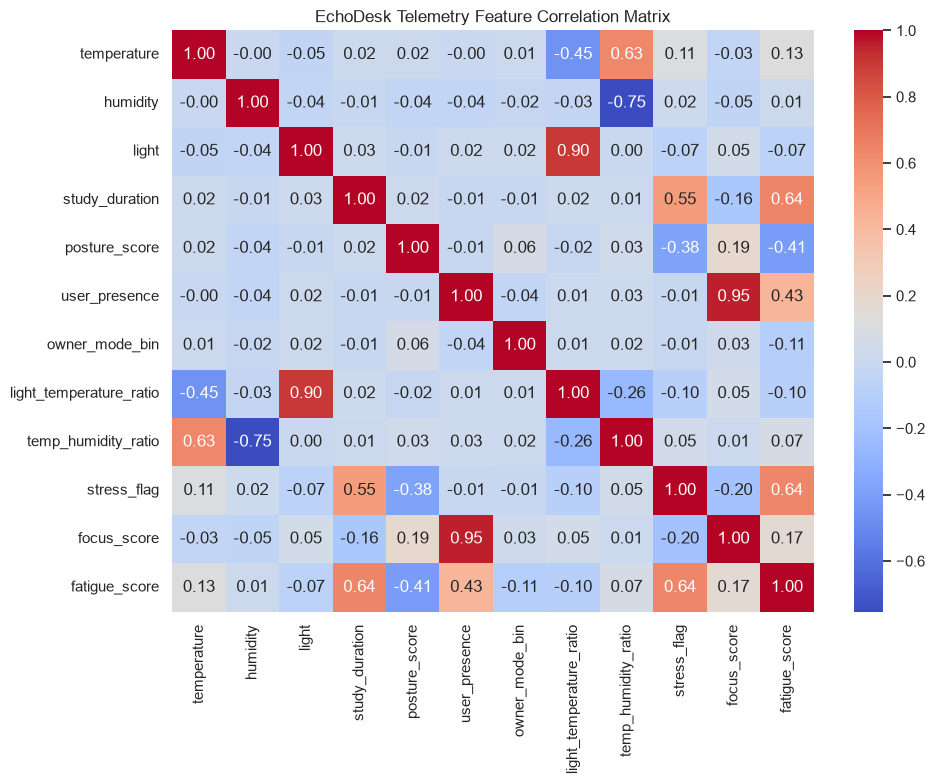

In [4]:
# Exploratory Data Analysis (EDA)
feature_cols = [
    'temperature', 'humidity', 'light', 'study_duration', 
    'posture_score', 'user_presence', 'owner_mode_bin', 
    'light_temperature_ratio', 'temp_humidity_ratio', 'stress_flag'
]

plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[feature_cols + ['focus_score', 'fatigue_score']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('EchoDesk Telemetry Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [5]:
# Train-Test Dataset Splitting
X = df_clean[feature_cols]
y_focus = df_clean['focus_score']
y_fatigue = df_clean['fatigue_score']

X_train, X_test, y_train, y_test = train_test_split(X, y_focus, test_size=0.20, random_state=42)
print(f'Training Samples: {X_train.shape[0]} | Testing Samples: {X_test.shape[0]}')

Training Samples: 960 | Testing Samples: 240


In [6]:
# Evaluate & Compare ML Regressors for Focus Score Prediction
models = {
    'Linear Regression': make_pipeline(StandardScaler(), LinearRegression()),
    'Decision Tree': make_pipeline(StandardScaler(), DecisionTreeRegressor(random_state=42)),
    'Random Forest': make_pipeline(StandardScaler(), RandomForestRegressor(n_estimators=100, random_state=42)),
    'Gradient Boosting': make_pipeline(StandardScaler(), GradientBoostingRegressor(n_estimators=100, random_state=42)),
    'Support Vector Regressor (SVR)': make_pipeline(StandardScaler(), SVR(C=10.0))
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append({
        'Model': name,
        'R2 Score': round(r2, 4),
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4)
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
print('=== MODEL COMPARISON LEADERBOARD ===')
print(results_df.to_string(index=False))

=== MODEL COMPARISON LEADERBOARD ===
                         Model  R2 Score    MAE   RMSE
             Gradient Boosting    0.9792 2.4460 3.1003
                 Random Forest    0.9760 2.5845 3.3324
             Linear Regression    0.9671 3.0211 3.9036
                 Decision Tree    0.9558 3.4758 4.5238
Support Vector Regressor (SVR)    0.9337 3.2664 5.5411


In [7]:
# Automatically Select and Export Best Model
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2 Score']
best_model = fitted_models[best_model_name]

print(f'\nBEST MODEL SELECTED: {best_model_name} (R2 Score: {best_r2})')

# Export trained model artifact
target_dir = 'ML'
if not os.path.exists(target_dir):
    os.makedirs(target_dir, exist_ok=True)

model_export_path = os.path.join(target_dir, 'focus_model.pkl')
joblib.dump(best_model, model_export_path)
# Also dump in current directory for redundant resolution
joblib.dump(best_model, 'focus_model.pkl')

print(f'Successfully serialized trained model to {model_export_path}')


BEST MODEL SELECTED: Gradient Boosting (R2 Score: 0.9792)
Successfully serialized trained model to ML\focus_model.pkl
